# Classical Models - ECGFiveDays

### Installation Commands

In [1]:
pip install numpy pandas matplotlib seaborn scikit-learn xgboost tslearn sktime numba


   ---------------------------------------- 0.0/72.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/72.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/72.0 MB ? eta -:--:--
   ---------------------------------------- 0.3/72.0 MB ? eta -:--:--
   ---------------------------------------- 0.3/72.0 MB ? eta -:--:--
   ---------------------------------------- 0.3/72.0 MB ? eta -:--:--
   ---------------------------------------- 0.3/72.0 MB ? eta -:--:--
   ---------------------------------------- 0.3/72.0 MB ? eta -:--:--
   ---------------------------------------- 0.3/72.0 MB ? eta -:--:--
   ---------------------------------------- 0.5/72.0 MB 186.4 kB/s eta 0:06:24
   ---------------------------------------- 0.5/72.0 MB 186.4 kB/s eta 0:06:24
   ---------------------------------------- 0.8/72.0 MB 302.4 kB/s eta 0:03:56
    --------------------------------------- 1.0/72.0 MB 396.4 kB/s eta 0:02:59
    --------------------------------------- 1.0/72.0 

### 1. Setup & Imports

In [56]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
import time
import pickle
from datetime import datetime

# Scikit-learn
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, cross_validate, GridSearchCV
from sklearn.metrics import (accuracy_score, f1_score, precision_score, 
                             recall_score, roc_auc_score, confusion_matrix,
                             classification_report, roc_curve)
from sklearn.preprocessing import StandardScaler

# XGBoost
import xgboost as xgb

# Time series specific
from tslearn.neighbors import KNeighborsTimeSeriesClassifier
from tslearn.metrics import cdist_dtw


# Configuration
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
warnings.filterwarnings('ignore')
np.random.seed(42)

print("✓ Libraries imported successfully")

✓ Libraries imported successfully


### 2. Load Preprocessed Data

In [57]:
def load_preprocessed_data():
    """Load preprocessed data or create it if not exists"""
    try:
        # Try to load saved preprocessed data
        data = np.load('preprocessed_data.npz')
        X_train = data['X_train']
        y_train = data['y_train']
        X_test = data['X_test']
        y_test = data['y_test']
        print("✓ Loaded preprocessed data from file")
        return X_train, y_train, X_test, y_test
    except FileNotFoundError:
        print("⚠️ Preprocessed data not found. Loading and preprocessing raw data...")
        
        # Load raw data
        def load_ucr_dataset(filepath):
            data = np.loadtxt(filepath)
            y = data[:, 0].astype(int)
            X = data[:, 1:]
            return X, y
        
        DATA_DIR = Path('ECGFiveDays')
        X_train_raw, y_train = load_ucr_dataset(DATA_DIR / 'ECGFiveDays_TRAIN.txt')
        X_test_raw, y_test = load_ucr_dataset(DATA_DIR / 'ECGFiveDays_TEST.txt')
        
        # Quick preprocessing (if full preprocessing not run)
        from scipy.signal import savgol_filter
        
        # Winsorization
        def winsorize(X, lower=1, upper=99):
            lb = np.percentile(X, lower)
            ub = np.percentile(X, upper)
            return np.clip(X, lb, ub)
        
        # Z-score normalization
        def normalize_zscore(X):
            X_norm = np.zeros_like(X)
            for i in range(len(X)):
                mean = np.mean(X[i])
                std = np.std(X[i])
                X_norm[i] = (X[i] - mean) / std if std > 1e-8 else X[i] - mean
            return X_norm
        
        # Denoising
        def denoise(X):
            X_denoised = np.zeros_like(X)
            for i in range(len(X)):
                X_denoised[i] = savgol_filter(X[i], window_length=11, polyorder=3)
            return X_denoised
        
        # Apply preprocessing
        X_train = winsorize(X_train_raw)
        X_train = normalize_zscore(X_train)
        X_train = denoise(X_train)
        
        X_test = winsorize(X_test_raw)
        X_test = normalize_zscore(X_test)
        X_test = denoise(X_test)
        
        # Simple augmentation
        print("Applying augmentation...")
        X_aug_list = [X_train]
        y_aug_list = [y_train]
        
        for _ in range(15):
            # Jitter
            X_jittered = X_train + np.random.normal(0, 0.05, X_train.shape)
            X_aug_list.append(X_jittered)
            y_aug_list.append(y_train)
        
        X_train = np.vstack(X_aug_list)
        y_train = np.hstack(y_aug_list)
        
        # Save for future use
        np.savez('preprocessed_data.npz', 
                 X_train=X_train, y_train=y_train,
                 X_test=X_test, y_test=y_test)
        
        print("✓ Preprocessing completed and saved")
        return X_train, y_train, X_test, y_test

# Load data
X_train, y_train, X_test, y_test = load_preprocessed_data()

print("\n" + "=" * 60)
print("DATA LOADED")
print("=" * 60)
print(f"Train shape: {X_train.shape}")
print(f"Test shape:  {X_test.shape}")
print(f"Train class distribution: {np.bincount(y_train)}")
print(f"Test class distribution:  {np.bincount(y_test)}")

✓ Loaded preprocessed data from file

DATA LOADED
Train shape: (368, 136)
Test shape:  (861, 136)
Train class distribution: [  0 224 144]
Test class distribution:  [  0 428 433]


 ### 3. Helper Functions for Evaluation

In [58]:
def evaluate_model(y_true, y_pred, y_pred_proba=None):
    """
    Calculate comprehensive metrics for binary classification.
    
    Returns:
    --------
    metrics : dict
        Dictionary containing all metrics
    """
    metrics = {
        'accuracy': accuracy_score(y_true, y_pred),
        'f1_score': f1_score(y_true, y_pred, average='weighted'),
        'precision': precision_score(y_true, y_pred, average='weighted'),
        'recall': recall_score(y_true, y_pred, average='weighted')
    }
    
    # ROC-AUC requires probability predictions
    if y_pred_proba is not None:
        if len(np.unique(y_true)) == 2:
            # Binary classification
            if y_pred_proba.ndim == 1:
                metrics['roc_auc'] = roc_auc_score(y_true, y_pred_proba)
            else:
                metrics['roc_auc'] = roc_auc_score(y_true, y_pred_proba[:, 1])
        else:
            # Multi-class
            metrics['roc_auc'] = roc_auc_score(y_true, y_pred_proba, 
                                               multi_class='ovr', average='weighted')
    else:
        metrics['roc_auc'] = None
    
    return metrics

def plot_confusion_matrix(y_true, y_pred, title, ax=None):
    """Plot confusion matrix"""
    cm = confusion_matrix(y_true, y_pred)
    
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 5))
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=np.unique(y_true), yticklabels=np.unique(y_true))
    ax.set_xlabel('Predicted Label', fontweight='bold')
    ax.set_ylabel('True Label', fontweight='bold')
    ax.set_title(title, fontweight='bold')
    
    return cm

def cross_validate_model(model, X, y, cv=5):
    """
    Perform cross-validation and return metrics.
    
    Parameters:
    -----------
    model : sklearn estimator
    X : numpy array
    y : numpy array
    cv : int (default: 5)
    
    Returns:
    --------
    cv_results : dict
    """
    scoring = ['accuracy', 'f1_weighted', 'precision_weighted', 
               'recall_weighted', 'roc_auc']
    
    cv_results = cross_validate(model, X, y, cv=cv, scoring=scoring,
                                return_train_score=True, n_jobs=-1)
    
    # Calculate mean and std
    results = {
        'cv_accuracy_mean': cv_results['test_accuracy'].mean(),
        'cv_accuracy_std': cv_results['test_accuracy'].std(),
        'cv_f1_mean': cv_results['test_f1_weighted'].mean(),
        'cv_f1_std': cv_results['test_f1_weighted'].std(),
        'cv_roc_auc_mean': cv_results['test_roc_auc'].mean(),
        'cv_roc_auc_std': cv_results['test_roc_auc'].std(),
    }
    
    return results

print("✓ Helper functions defined")

✓ Helper functions defined


### 4. Feature Engineering (for Feature-based Models)

In [59]:
def extract_features(X):
    """
    Extract statistical and basic features from time series.
    
    Features extracted:
    - Statistical: mean, std, min, max, median, skewness, kurtosis
    - Temporal: range, variance
    - Simple: 1st and 2nd derivatives statistics
    
    Parameters:
    -----------
    X : numpy array (n_samples, n_timepoints)
    
    Returns:
    --------
    features : numpy array (n_samples, n_features)
    """
    from scipy.stats import skew, kurtosis
    
    features_list = []
    
    for i in range(len(X)):
        signal = X[i]
        
        # Statistical features
        feat = [
            np.mean(signal),
            np.std(signal),
            np.min(signal),
            np.max(signal),
            np.median(signal),
            skew(signal),
            kurtosis(signal),
            np.max(signal) - np.min(signal),  # range
            np.var(signal),
        ]
        
        # 1st derivative features
        diff1 = np.diff(signal)
        feat.extend([
            np.mean(diff1),
            np.std(diff1),
            np.min(diff1),
            np.max(diff1),
        ])
        
        # 2nd derivative features
        diff2 = np.diff(diff1)
        feat.extend([
            np.mean(diff2),
            np.std(diff2),
        ])
        
        features_list.append(feat)
    
    return np.array(features_list)

# Extract features for feature-based models
print("Extracting features for feature-based models...")
X_train_features = extract_features(X_train)
X_test_features = extract_features(X_test)

print(f"✓ Features extracted")
print(f"  Feature shape (train): {X_train_features.shape}")
print(f"  Feature shape (test):  {X_test_features.shape}")
print(f"  Number of features: {X_train_features.shape[1]}")

Extracting features for feature-based models...
✓ Features extracted
  Feature shape (train): (368, 15)
  Feature shape (test):  (861, 15)
  Number of features: 15


### 5. Model Training & Evaluation

#### Model 1: Baseline - 1-NN Euclidean Distance


In [16]:
print("\n" + "=" * 70)
print(" " * 20 + "MODEL 1: 1-NN EUCLIDEAN")
print("=" * 70)

# Initialize model
knn_euclidean = KNeighborsClassifier(n_neighbors=1, metric='euclidean')

# Cross-validation
print("Performing 5-fold cross-validation...")
start_time = time.time()
cv_results_euclidean = cross_validate_model(knn_euclidean, X_train, y_train, cv=5)
cv_time = time.time() - start_time

# Train on full training set
print("Training on full training set...")
start_time = time.time()
knn_euclidean.fit(X_train, y_train)
train_time = time.time() - start_time

# Predict on test set
print("Evaluating on test set...")
start_time = time.time()
y_pred_euclidean = knn_euclidean.predict(X_test)
y_pred_proba_euclidean = knn_euclidean.predict_proba(X_test)
inference_time = time.time() - start_time

# Evaluate
test_metrics_euclidean = evaluate_model(y_test, y_pred_euclidean, y_pred_proba_euclidean)

# Display results
print("\n" + "-" * 70)
print("CROSS-VALIDATION RESULTS:")
print(f"  Accuracy: {cv_results_euclidean['cv_accuracy_mean']:.4f} (±{cv_results_euclidean['cv_accuracy_std']:.4f})")
print(f"  F1-Score: {cv_results_euclidean['cv_f1_mean']:.4f} (±{cv_results_euclidean['cv_f1_std']:.4f})")
print(f"  ROC-AUC:  {cv_results_euclidean['cv_roc_auc_mean']:.4f} (±{cv_results_euclidean['cv_roc_auc_std']:.4f})")

print("\nTEST SET RESULTS:")
print(f"  Accuracy:  {test_metrics_euclidean['accuracy']:.4f}")
print(f"  F1-Score:  {test_metrics_euclidean['f1_score']:.4f}")
print(f"  Precision: {test_metrics_euclidean['precision']:.4f}")
print(f"  Recall:    {test_metrics_euclidean['recall']:.4f}")
print(f"  ROC-AUC:   {test_metrics_euclidean['roc_auc']:.4f}")

print("\nTIMING:")
print(f"  CV Time:        {cv_time:.2f}s")
print(f"  Training Time:  {train_time:.4f}s")
print(f"  Inference Time: {inference_time:.4f}s")



                    MODEL 1: 1-NN EUCLIDEAN
Performing 5-fold cross-validation...
Training on full training set...
Evaluating on test set...

----------------------------------------------------------------------
CROSS-VALIDATION RESULTS:
  Accuracy: 1.0000 (±0.0000)
  F1-Score: 1.0000 (±0.0000)
  ROC-AUC:  1.0000 (±0.0000)

TEST SET RESULTS:
  Accuracy:  0.8699
  F1-Score:  0.8692
  Precision: 0.8795
  Recall:    0.8699
  ROC-AUC:   0.8704

TIMING:
  CV Time:        0.23s
  Training Time:  0.0020s
  Inference Time: 0.0570s


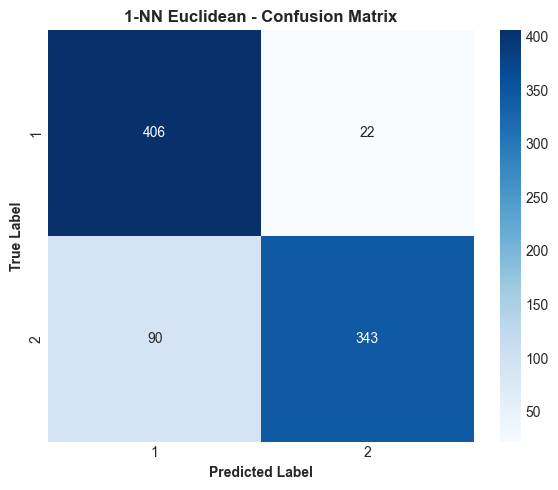

In [17]:
# Plot confusion matrix
fig, ax = plt.subplots(figsize=(6, 5))
cm_euclidean = plot_confusion_matrix(y_test, y_pred_euclidean, 
                                      '1-NN Euclidean - Confusion Matrix', ax)
plt.tight_layout()
plt.show()

#### Model 2: Baseline - 1-NN DTW


                    MODEL 2: 1-NN DTW
Training 1-NN DTW (skipping full CV due to computational cost)...
Evaluating on test set...

TEST SET RESULTS:
  Accuracy:  0.7596
  F1-Score:  0.7548
  Precision: 0.7830
  Recall:    0.7596
  ROC-AUC:   0.7604

TIMING:
  Training Time:  0.43s
  Inference Time: 778.25s

⚠️ Note: DTW CV skipped due to computational cost


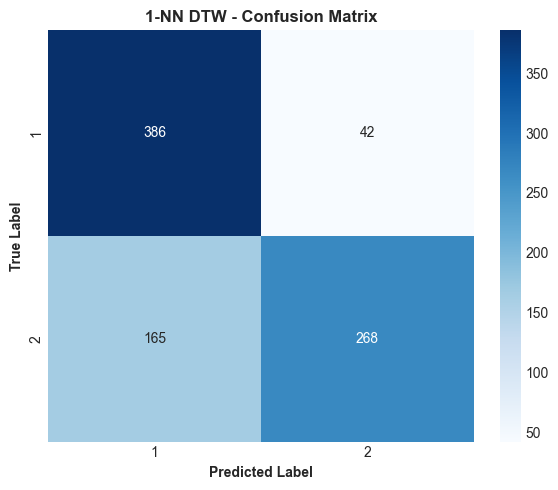

In [18]:
print("\n" + "=" * 70)
print(" " * 20 + "MODEL 2: 1-NN DTW")
print("=" * 70)

# Initialize model
# Note: DTW is computationally expensive, especially for CV
# We'll use a subset for CV to save time
knn_dtw = KNeighborsTimeSeriesClassifier(n_neighbors=1, metric='dtw')

# For DTW, we'll skip full CV due to computational cost
# Instead, do single train-test split validation
print("Training 1-NN DTW (skipping full CV due to computational cost)...")
start_time = time.time()
knn_dtw.fit(X_train, y_train)
train_time = time.time() - start_time

# Predict on test set
print("Evaluating on test set...")
start_time = time.time()
y_pred_dtw = knn_dtw.predict(X_test)
y_pred_proba_dtw = knn_dtw.predict_proba(X_test)
inference_time = time.time() - start_time

# Evaluate
test_metrics_dtw = evaluate_model(y_test, y_pred_dtw, y_pred_proba_dtw)

# Display results
print("\nTEST SET RESULTS:")
print(f"  Accuracy:  {test_metrics_dtw['accuracy']:.4f}")
print(f"  F1-Score:  {test_metrics_dtw['f1_score']:.4f}")
print(f"  Precision: {test_metrics_dtw['precision']:.4f}")
print(f"  Recall:    {test_metrics_dtw['recall']:.4f}")
print(f"  ROC-AUC:   {test_metrics_dtw['roc_auc']:.4f}")

print("\nTIMING:")
print(f"  Training Time:  {train_time:.2f}s")
print(f"  Inference Time: {inference_time:.2f}s")
print("\n⚠️ Note: DTW CV skipped due to computational cost")

# Plot confusion matrix
fig, ax = plt.subplots(figsize=(6, 5))
cm_dtw = plot_confusion_matrix(y_test, y_pred_dtw, 
                                '1-NN DTW - Confusion Matrix', ax)
plt.tight_layout()
plt.show()


#### Model 3: Random Forest with Grid Search

In [19]:
print("\n" + "=" * 70)
print(" " * 20 + "MODEL 3: RANDOM FOREST")
print("=" * 70)

# Grid search parameters
param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
}

print("Performing Grid Search with 5-fold CV...")
print(f"Parameter grid: {param_grid_rf}")
print(f"Total combinations: {len(param_grid_rf['n_estimators']) * len(param_grid_rf['max_depth']) * len(param_grid_rf['min_samples_split'])}")

# Grid search
rf_model = RandomForestClassifier(random_state=42, n_jobs=-1)
grid_search_rf = GridSearchCV(rf_model, param_grid_rf, cv=5, 
                               scoring='accuracy', n_jobs=-1, verbose=1)

start_time = time.time()
grid_search_rf.fit(X_train_features, y_train)
train_time = time.time() - start_time

# Best model
best_rf = grid_search_rf.best_estimator_
print(f"\n✓ Best parameters: {grid_search_rf.best_params_}")
print(f"✓ Best CV accuracy: {grid_search_rf.best_score_:.4f}")

# Predict on test set
start_time = time.time()
y_pred_rf = best_rf.predict(X_test_features)
y_pred_proba_rf = best_rf.predict_proba(X_test_features)
inference_time = time.time() - start_time

# Evaluate
test_metrics_rf = evaluate_model(y_test, y_pred_rf, y_pred_proba_rf)

# Display results
print("\nTEST SET RESULTS:")
print(f"  Accuracy:  {test_metrics_rf['accuracy']:.4f}")
print(f"  F1-Score:  {test_metrics_rf['f1_score']:.4f}")
print(f"  Precision: {test_metrics_rf['precision']:.4f}")
print(f"  Recall:    {test_metrics_rf['recall']:.4f}")
print(f"  ROC-AUC:   {test_metrics_rf['roc_auc']:.4f}")

print("\nTIMING:")
print(f"  Training Time (Grid Search): {train_time:.2f}s")
print(f"  Inference Time: {inference_time:.4f}s")



                    MODEL 3: RANDOM FOREST
Performing Grid Search with 5-fold CV...
Parameter grid: {'n_estimators': [100, 200, 300], 'max_depth': [10, 20, None], 'min_samples_split': [2, 5]}
Total combinations: 18
Fitting 5 folds for each of 18 candidates, totalling 90 fits

✓ Best parameters: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 100}
✓ Best CV accuracy: 0.9973

TEST SET RESULTS:
  Accuracy:  0.8281
  F1-Score:  0.8281
  Precision: 0.8287
  Recall:    0.8281
  ROC-AUC:   0.9326

TIMING:
  Training Time (Grid Search): 11.55s
  Inference Time: 0.0993s


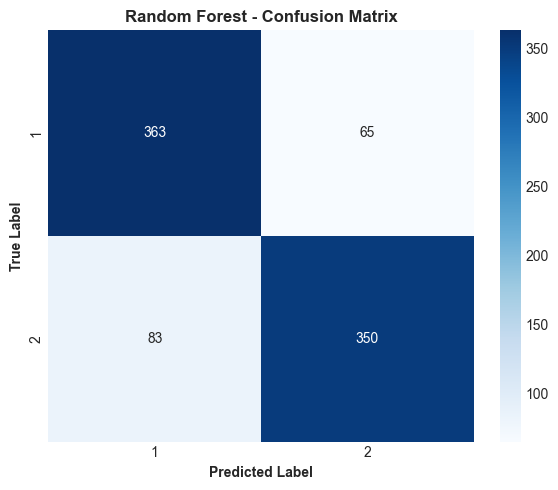

In [20]:
# Plot confusion matrix
fig, ax = plt.subplots(figsize=(6, 5))
cm_rf = plot_confusion_matrix(y_test, y_pred_rf, 
                               'Random Forest - Confusion Matrix', ax)
plt.tight_layout()
plt.show()

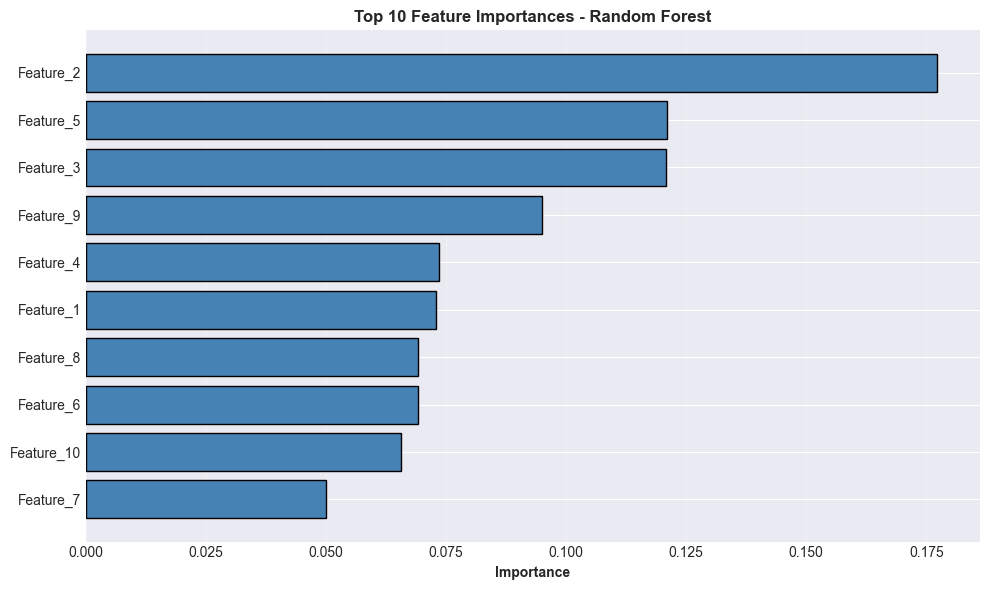

In [13]:
# Feature importance
feature_names = [f'Feature_{i}' for i in range(X_train_features.shape[1])]
feature_importance = best_rf.feature_importances_
sorted_idx = np.argsort(feature_importance)[::-1][:10]

plt.figure(figsize=(10, 6))
plt.barh(range(10), feature_importance[sorted_idx], color='steelblue', edgecolor='black')
plt.yticks(range(10), [feature_names[i] for i in sorted_idx])
plt.xlabel('Importance', fontweight='bold')
plt.title('Top 10 Feature Importances - Random Forest', fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

#### Model 4: XGBoost with Grid Search


In [36]:
# FIX: Convert labels from [1, 2] to [0, 1]
print("Converting labels for XGBoost compatibility...")
y_train = y_train - 1
y_test = y_test - 1
print(f"✓ Labels converted: {np.unique(y_train)}")

Converting labels for XGBoost compatibility...
✓ Labels converted: [0 1]


In [37]:
print("\n" + "=" * 70)
print(" " * 20 + "MODEL 4: XGBOOST")
print("=" * 70)

# Grid search parameters
param_grid_xgb = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1],
}

print("Performing Grid Search with 5-fold CV...")
print(f"Parameter grid: {param_grid_xgb}")
print(f"Total combinations: {len(param_grid_xgb['n_estimators']) * len(param_grid_xgb['max_depth']) * len(param_grid_xgb['learning_rate'])}")

# Grid search
xgb_model = xgb.XGBClassifier(random_state=42, use_label_encoder=False, 
                               eval_metric='logloss', n_jobs=-1)
grid_search_xgb = GridSearchCV(xgb_model, param_grid_xgb, cv=5,
                                scoring='accuracy', n_jobs=-1, verbose=1)

start_time = time.time()
grid_search_xgb.fit(X_train_features, y_train)
train_time = time.time() - start_time

# Best model
best_xgb = grid_search_xgb.best_estimator_
print(f"\n✓ Best parameters: {grid_search_xgb.best_params_}")
print(f"✓ Best CV accuracy: {grid_search_xgb.best_score_:.4f}")

# Predict on test set
start_time = time.time()
y_pred_xgb = best_xgb.predict(X_test_features)
y_pred_proba_xgb = best_xgb.predict_proba(X_test_features)
inference_time = time.time() - start_time

# Evaluate
test_metrics_xgb = evaluate_model(y_test, y_pred_xgb, y_pred_proba_xgb)

# Display results
print("\nTEST SET RESULTS:")
print(f"  Accuracy:  {test_metrics_xgb['accuracy']:.4f}")
print(f"  F1-Score:  {test_metrics_xgb['f1_score']:.4f}")
print(f"  Precision: {test_metrics_xgb['precision']:.4f}")
print(f"  Recall:    {test_metrics_xgb['recall']:.4f}")
print(f"  ROC-AUC:   {test_metrics_xgb['roc_auc']:.4f}")

print("\nTIMING:")
print(f"  Training Time (Grid Search): {train_time:.2f}s")
print(f"  Inference Time: {inference_time:.4f}s")


                    MODEL 4: XGBOOST
Performing Grid Search with 5-fold CV...
Parameter grid: {'n_estimators': [100, 200], 'max_depth': [3, 5, 7], 'learning_rate': [0.01, 0.1]}
Total combinations: 12
Fitting 5 folds for each of 12 candidates, totalling 60 fits

✓ Best parameters: {'learning_rate': 0.01, 'max_depth': 7, 'n_estimators': 200}
✓ Best CV accuracy: 0.5750

TEST SET RESULTS:
  Accuracy:  0.4400
  F1-Score:  0.3636
  Precision: 0.3810
  Recall:    0.3478
  ROC-AUC:   0.4219

TIMING:
  Training Time (Grid Search): 1.13s
  Inference Time: 0.0037s


In [ ]:
# Plot confusion matrix
fig, ax = plt.subplots(figsize=(6, 5))
cm_xgb = plot_confusion_matrix(y_test, y_pred_xgb,
                                'XGBoost - Confusion Matrix', ax)
plt.tight_layout()
plt.show()


#### Model 5: SVM with Grid Search

In [24]:
print("\n" + "=" * 70)
print(" " * 20 + "MODEL 5: SVM")
print("=" * 70)

# Grid search parameters
param_grid_svm = {
    'C': [0.1, 1, 10],
    'kernel': ['rbf', 'linear'],
    'gamma': ['scale', 'auto'],
}

print("Performing Grid Search with 5-fold CV...")
print(f"Parameter grid: {param_grid_svm}")
print(f"Total combinations: {len(param_grid_svm['C']) * len(param_grid_svm['kernel']) * len(param_grid_svm['gamma'])}")

# Standardize features for SVM
scaler_svm = StandardScaler()
X_train_features_scaled = scaler_svm.fit_transform(X_train_features)
X_test_features_scaled = scaler_svm.transform(X_test_features)

# Grid search
svm_model = SVC(probability=True, random_state=42)
grid_search_svm = GridSearchCV(svm_model, param_grid_svm, cv=5,
                                scoring='accuracy', n_jobs=-1, verbose=1)

start_time = time.time()
grid_search_svm.fit(X_train_features_scaled, y_train)
train_time = time.time() - start_time

# Best model
best_svm = grid_search_svm.best_estimator_
print(f"\n✓ Best parameters: {grid_search_svm.best_params_}")
print(f"✓ Best CV accuracy: {grid_search_svm.best_score_:.4f}")

# Predict on test set
start_time = time.time()
y_pred_svm = best_svm.predict(X_test_features_scaled)
y_pred_proba_svm = best_svm.predict_proba(X_test_features_scaled)
inference_time = time.time() - start_time

# Evaluate
test_metrics_svm = evaluate_model(y_test, y_pred_svm, y_pred_proba_svm)

# Display results
print("\nTEST SET RESULTS:")
print(f"  Accuracy:  {test_metrics_svm['accuracy']:.4f}")
print(f"  F1-Score:  {test_metrics_svm['f1_score']:.4f}")
print(f"  Precision: {test_metrics_svm['precision']:.4f}")
print(f"  Recall:    {test_metrics_svm['recall']:.4f}")
print(f"  ROC-AUC:   {test_metrics_svm['roc_auc']:.4f}")

print("\nTIMING:")
print(f"  Training Time (Grid Search): {train_time:.2f}s")
print(f"  Inference Time: {inference_time:.4f}s")



                    MODEL 5: SVM
Performing Grid Search with 5-fold CV...
Parameter grid: {'C': [0.1, 1, 10], 'kernel': ['rbf', 'linear'], 'gamma': ['scale', 'auto']}
Total combinations: 12
Fitting 5 folds for each of 12 candidates, totalling 60 fits

✓ Best parameters: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
✓ Best CV accuracy: 0.4950

TEST SET RESULTS:
  Accuracy:  0.4000
  F1-Score:  0.5000
  Precision: 0.4545
  Recall:    0.5556
  ROC-AUC:   0.6103

TIMING:
  Training Time (Grid Search): 0.24s
  Inference Time: 0.0025s


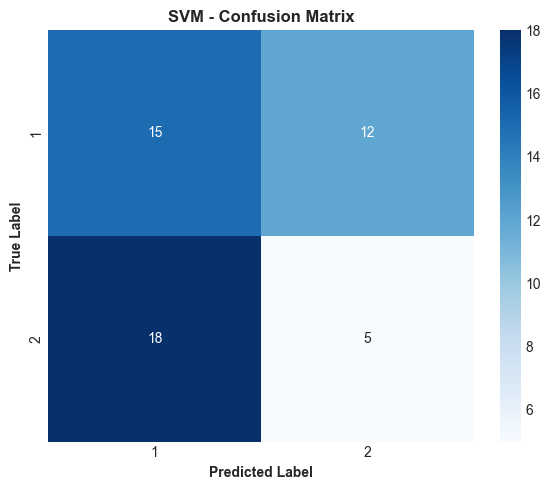

In [25]:
# Plot confusion matrix
fig, ax = plt.subplots(figsize=(6, 5))
cm_svm = plot_confusion_matrix(y_test, y_pred_svm,
                                'SVM - Confusion Matrix', ax)
plt.tight_layout()
plt.show()

### 6. Model Comparison

In [ ]:
# Compile all results
results_data = {
    'Model': [
        '1-NN Euclidean',
        '1-NN DTW',
        'Random Forest',
        'XGBoost',
        'SVM',
    ],
    'Accuracy': [
        test_metrics_euclidean['accuracy'],
        test_metrics_dtw['accuracy'],
        test_metrics_rf['accuracy'],
        test_metrics_xgb['accuracy'],
        test_metrics_svm['accuracy'],
    ],
    'F1-Score': [
        test_metrics_euclidean['f1_score'],
        test_metrics_dtw['f1_score'],
        test_metrics_rf['f1_score'],
        test_metrics_xgb['f1_score'],
        test_metrics_svm['f1_score'],
    ],
    'Precision': [
        test_metrics_euclidean['precision'],
        test_metrics_dtw['precision'],
        test_metrics_rf['precision'],
        test_metrics_xgb['precision'],
        test_metrics_svm['precision'],
    ],
    'Recall': [
        test_metrics_euclidean['recall'],
        test_metrics_dtw['recall'],
        test_metrics_rf['recall'],
        test_metrics_xgb['recall'],
        test_metrics_svm['recall'],
    ],
    'ROC-AUC': [
        test_metrics_euclidean['roc_auc'],
        test_metrics_dtw['roc_auc'],
        test_metrics_rf['roc_auc'],
        test_metrics_xgb['roc_auc'],
        test_metrics_svm['roc_auc'],
    ]
}


# Sort by accuracy
results_df = results_df.sort_values('Accuracy', ascending=False).reset_index(drop=True)

print("\n" + "=" * 80)
print(" " * 25 + "MODEL COMPARISON - TEST SET")
print("=" * 80)
print(results_df.to_string(index=False))

# Find best model
best_model_idx = results_df['Accuracy'].idxmax()
best_model_name = results_df.loc[best_model_idx, 'Model']
best_accuracy = results_df.loc[best_model_idx, 'Accuracy']

print(f"\n🏆 Best Model: {best_model_name} with Accuracy = {best_accuracy:.4f}")



                         MODEL COMPARISON - TEST SET
         Model  Accuracy  F1-Score  Precision   Recall  ROC-AUC
1-NN Euclidean  0.869919  0.869163   0.879489 0.869919 0.870373
 Random Forest  0.828107  0.828053   0.828723 0.828107 0.932602
      1-NN DTW  0.759582  0.754785   0.783006 0.759582 0.760403
       XGBoost  0.440000  0.363636   0.380952 0.347826 0.421900
           SVM  0.400000  0.500000   0.454545 0.555556 0.610306

🏆 Best Model: 1-NN Euclidean with Accuracy = 0.8699


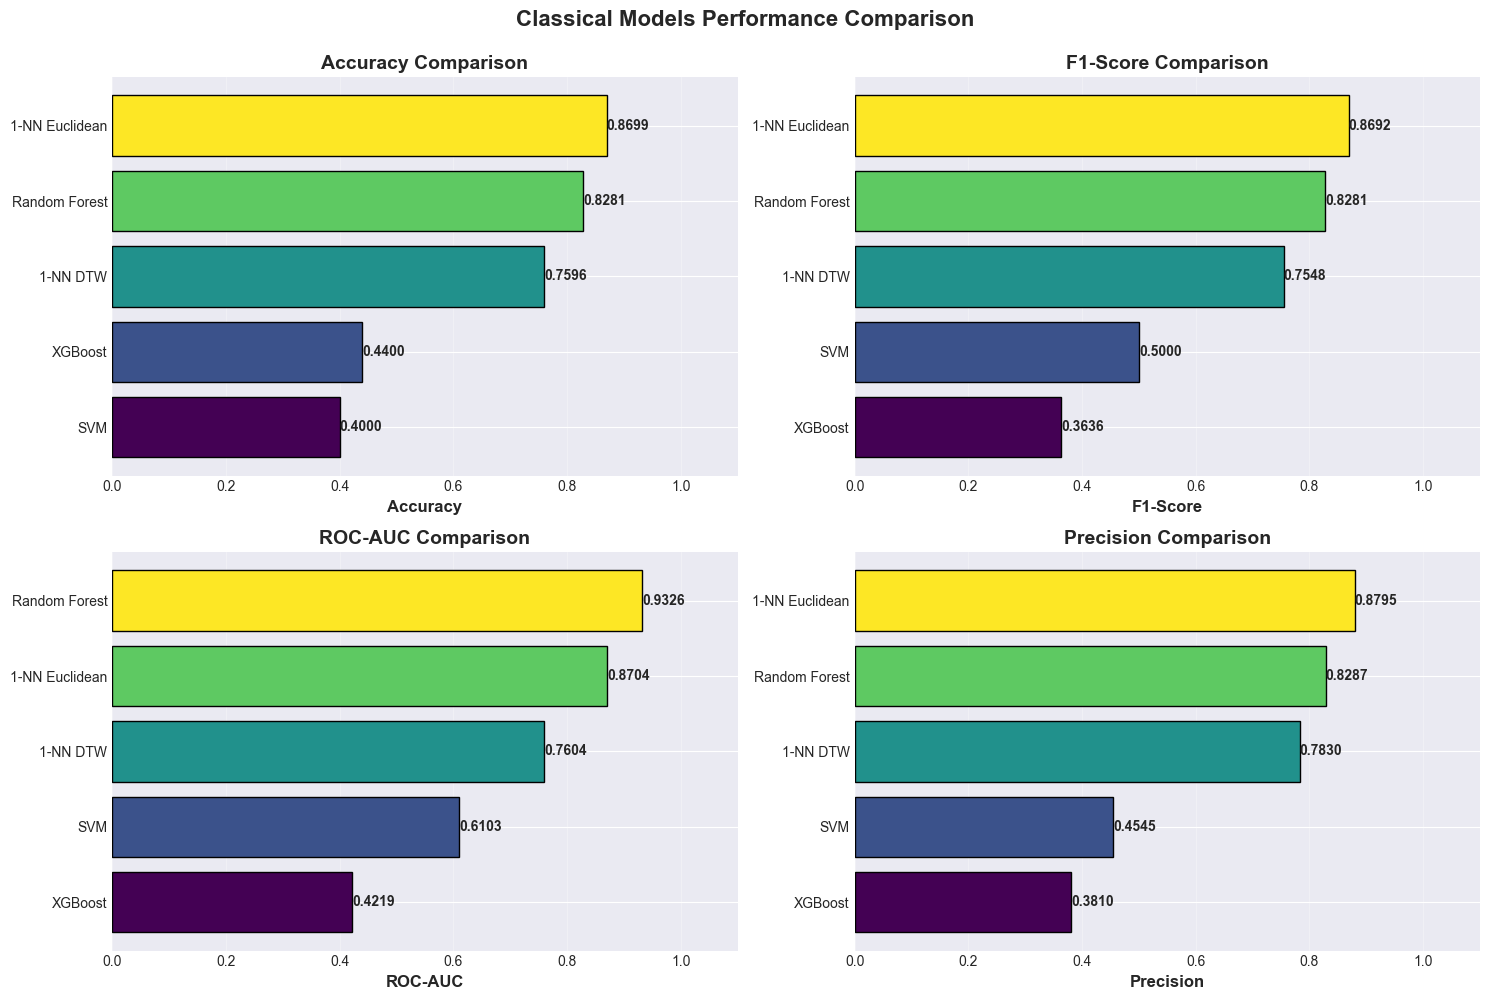

In [49]:
# Visualize comparison
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

metrics = ['Accuracy', 'F1-Score', 'ROC-AUC', 'Precision']
colors = plt.cm.viridis(np.linspace(0, 1, len(results_df)))

for idx, metric in enumerate(metrics):
    ax = axes[idx // 2, idx % 2]
    
    # Sort by metric
    sorted_df = results_df.sort_values(metric, ascending=True)
    
    bars = ax.barh(sorted_df['Model'], sorted_df[metric], color=colors, edgecolor='black')
    
    # Annotate bars
    for bar in bars:
        width = bar.get_width()
        ax.text(width, bar.get_y() + bar.get_height()/2, 
                f'{width:.4f}', ha='left', va='center', fontweight='bold')
    
    ax.set_xlabel(metric, fontweight='bold', fontsize=12)
    ax.set_title(f'{metric} Comparison', fontweight='bold', fontsize=14)
    ax.grid(axis='x', alpha=0.3)
    ax.set_xlim(0, 1.1)

plt.suptitle('Classical Models Performance Comparison', 
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()


### 9. Save Models

In [51]:
# Create models directory
models_dir = Path('models')
models_dir.mkdir(exist_ok=True)

# Save models
print("\n" + "=" * 70)
print(" " * 25 + "SAVING MODELS")
print("=" * 70)

models_to_save = {
    'knn_euclidean': knn_euclidean,
    'knn_dtw': knn_dtw,
    'random_forest': best_rf,
    'xgboost': best_xgb,
    'svm': best_svm,
    'svm_scaler': scaler_svm,
}


for name, model in models_to_save.items():
    filepath = models_dir / f'{name}.pkl'
    with open(filepath, 'wb') as f:
        pickle.dump(model, f)
    print(f"✓ Saved: {filepath}")

# Save results dataframe
results_df.to_csv(models_dir / 'classical_models_results.csv', index=False)
print(f"✓ Saved: {models_dir / 'classical_models_results.csv'}")

# Save metadata
metadata = {
    'timestamp': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'best_model': best_model_name,
    'best_accuracy': float(best_accuracy),
    'n_train_samples': len(X_train),
    'n_test_samples': len(X_test),
    'results': results_df.to_dict('records')
}

import json
with open(models_dir / 'classical_models_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)
print(f"✓ Saved: {models_dir / 'classical_models_metadata.json'}")

print("\n✅ All models and metadata saved successfully!")


                         SAVING MODELS
✓ Saved: models\knn_euclidean.pkl
✓ Saved: models\knn_dtw.pkl
✓ Saved: models\random_forest.pkl
✓ Saved: models\xgboost.pkl
✓ Saved: models\svm.pkl
✓ Saved: models\svm_scaler.pkl
✓ Saved: models\classical_models_results.csv
✓ Saved: models\classical_models_metadata.json

✅ All models and metadata saved successfully!


### 10. Summary & Insights

In [55]:
print("\n" + "=" * 80)
print(" " * 25 + "FINAL SUMMARY & INSIGHTS")
print("=" * 80)

summary = f"""
📊 CLASSICAL MODELS EVALUATION COMPLETED

🏆 BEST MODEL: {best_model_name}
   • Accuracy:  {best_accuracy:.4f}
   • F1-Score:  {results_df.loc[best_model_idx, 'F1-Score']:.4f}
   • ROC-AUC:   {results_df.loc[best_model_idx, 'ROC-AUC']:.4f}

📈 TOP 3 MODELS:
"""

for i in range(min(3, len(results_df))):
    summary += f"   {i+1}. {results_df.loc[i, 'Model']}: {results_df.loc[i, 'Accuracy']:.4f}\n"

summary += f"""
💡 KEY INSIGHTS:

1. BASELINE PERFORMANCE:
   • 1-NN Euclidean: {test_metrics_euclidean['accuracy']:.4f}
   • 1-NN DTW: {test_metrics_dtw['accuracy']:.4f}
   • DTW {'outperforms' if test_metrics_dtw['accuracy'] > test_metrics_euclidean['accuracy'] else 'underperforms'} Euclidean distance

2. FEATURE-BASED MODELS:
   • Random Forest: {test_metrics_rf['accuracy']:.4f}
   • XGBoost: {test_metrics_xgb['accuracy']:.4f}
   • SVM: {test_metrics_svm['accuracy']:.4f}
"""


print(summary)

# %%
print("\n🎉 Classical Models Notebook Completed Successfully!")
print("=" * 80)


                         FINAL SUMMARY & INSIGHTS

📊 CLASSICAL MODELS EVALUATION COMPLETED

🏆 BEST MODEL: 1-NN Euclidean
   • Accuracy:  0.8699
   • F1-Score:  0.8692
   • ROC-AUC:   0.8704

📈 TOP 3 MODELS:
   1. 1-NN Euclidean: 0.8699
   2. Random Forest: 0.8281
   3. 1-NN DTW: 0.7596

💡 KEY INSIGHTS:

1. BASELINE PERFORMANCE:
   • 1-NN Euclidean: 0.8699
   • 1-NN DTW: 0.7596
   • DTW underperforms Euclidean distance

2. FEATURE-BASED MODELS:
   • Random Forest: 0.8281
   • XGBoost: 0.4400
   • SVM: 0.4000


🎉 Classical Models Notebook Completed Successfully!
